# Stock Sentiment Prediction with LSTM

# Sentiment-Aware Stock Prediction with LSTM

## 1. Install & Import Dependencies

In [7]:

# !pip install transformers --quiet
# !pip install torch --quiet

import pandas as pd
import numpy as np
from datetime import datetime
from transformers import pipeline
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Dropout
# from tensorflow.keras.callbacks import EarlyStopping

## 2. Load and Merge Financial News Data

In [8]:
import os
import pandas as pd

# Path to your data directory
news_parts_dir = "./data/s3_csv/"

# Define starting part number
start_part = 45
# List and filter CSV files
all_parts = sorted([
    f for f in os.listdir(news_parts_dir)
    if f.startswith("part-000") and f.endswith(".csv")
])
# Filter files by part number
filtered_parts = [
    f for f in all_parts
    if int(f.split('-')[1]) >= start_part
]
# Load and concatenate filtered files
news_df = pd.concat(
    [pd.read_csv(os.path.join(news_parts_dir, f)) for f in filtered_parts],
    ignore_index=True
)
# Convert dates and drop rows with missing content or dates
news_df["date_published"] = pd.to_datetime(news_df["date_published"], errors="coerce")
news_df = news_df.dropna(subset=["article_content", "date_published"])
# Preview
news_df.head()

,id,date_published,title,url,stock_symbols,keywords,datetime_published,date_modified,article_content,processed
0,840172,2018-12-09,$80 Million ICO TenX Founder Linked to Pyramid...,https://finance.yahoo.com/news/80-million-ico-...,[],"[""TenX"", ""Lyoness"", ""Julian Hosp""]",NaN,2018-12-09 11:30:08,Ten X president Julian Hosp has reportedly bee...,0
1,840173,2018-12-09,"Hong Kong, China bourses reach deal on dual-cl...",https://www.yahoo.com/news/hong-kong-china-bou...,[],"[""Hong Kong stock exchange"", ""Hong Kong""]",NaN,2018-12-09 11:39:02,"H ON G K ON G, Dec 9 (Reuters) - The Hong Kong...",0
2,840174,2018-12-09,5 Ways to Land Your Dream Job in 2019,https://finance.yahoo.com/news/5-ways-land-dre...,[],"[""dream job""]",NaN,2018-12-09 11:57:00,What's your idea of a dream job? It is being p...,0
3,840175,2018-12-09,Volkswagen denies allegations chairman knew ea...,https://www.yahoo.com/news/volkswagen-denies-a...,[],"[""Volkswagen"", ""Hans Dieter Poetsch"", ""market ...",NaN,2018-12-09 11:57:55,F RA NK FU RT (Reuters) - Volkswagen has denie...,0
4,840176,2018-12-09,Crypto Exchange Gemini Lists Bitcoin Cash with...,https://finance.yahoo.com/news/crypto-exchange...,[],"[""Bitcoin Cash"", ""International Securities Exc...",NaN,2018-12-09 11:59:40,Crypto exchange Gemini has announced that it n...,0


## 3. Run FinBERT for Sentiment Analysis

In [6]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TextClassificationPipeline
from tqdm import tqdm

# Explicitly load the tokenizer and model for FinBERT
tokenizer = AutoTokenizer.from_pretrained("yiyanghkust/finbert-tone")
model = AutoModelForSequenceClassification.from_pretrained("yiyanghkust/finbert-tone")

# Create the pipeline with our explicitly loaded model and tokenizer
finbert = TextClassificationPipeline(
    model=model,
    tokenizer=tokenizer,
    truncation=True,  # Enable automatic truncation of long texts
)

# Function to compute sentiment score: Positive - Negative
def get_sentiment_score(text):
    try:
        # Pass the text directly; the pipeline now handles truncation automatically.
        result = finbert(text)[0]
        label = result["label"].lower()
        score = result["score"]
        if label == "positive":
            return score
        elif label == "negative":
            return -score
        else:
            return 0.0  # You might consider customizing this for neutral labels if needed.
    except Exception as e:
        # Optionally print the error to debug individual cases: print(e)
        return 0.0  # Return a neutral score if an error occurs

# Enable progress_apply on your DataFrame
tqdm.pandas()
news_df["sentiment_score"] = news_df["article_content"].progress_apply(get_sentiment_score)

Device set to use mps:0


NameError: name 'news_df' is not defined

## 4. Aggregate Daily Sentiment

In [ ]:

daily_sentiment = news_df.groupby(news_df["date_published"].dt.date)["sentiment_score"].mean().reset_index()
daily_sentiment.columns = ["date", "avg_sentiment"]
daily_sentiment["date"] = pd.to_datetime(daily_sentiment["date"])
daily_sentiment.head()

## 5. Load Stock Data and Merge Sentiment

In [2]:

stock_df = pd.read_csv("./data/raw/AAPL.csv")
stock_df["date"] = pd.to_datetime(stock_df["Date"])
# merged_df = pd.merge(stock_df, daily_sentiment, on="date", how="left")
# merged_df["avg_sentiment"] = merged_df["avg_sentiment"].fillna(0)
# merged_df = merged_df.sort_values("date")
# merged_df.head()

## 6. Train/Test Split and Normalization

In [3]:

# features = ["open", "high", "low", "close", "volume", "avg_sentiment"]
features = ["Open", "High", "Low", "Close", "Volume"]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(stock_df[features])

sequence_length = 30
X, y = [], []
for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i, features.index("Close")])  # predict close

X, y = np.array(X), np.array(y)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

## 7. Build and Train LSTM Model

In [4]:
import tensorflow.keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mean_squared_error")
early_stop = EarlyStopping(monitor='val_loss', patience=10)

history = model.fit(X_train, y_train, epochs=50, batch_size=32,
                    validation_split=0.1, callbacks=[early_stop])

Epoch 1/50


/Users/nickyjosephson/Desktop/Personal/ML-Stock-Prediction/stock-forecast-env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0027 - val_loss: 0.0017
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2.1872e-04 - val_loss: 0.0010
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2.0057e-04 - val_loss: 7.3335e-04
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.6220e-04 - val_loss: 6.0612e-04
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.7438e-04 - val_loss: 7.3701e-04
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 1.4074e-04 - val_loss: 6.7671e-04
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.3332e-04 - val_loss: 6.1043e-04
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.1832e-04 - val_loss: 7.2026e-04
Epoch 9/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.1771e-04 - val_loss: 8.8481e-04
Epoch 10/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.3451e-04 - val_loss: 6.2895e-04
Epoch 11/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.0801e-04 - val_loss: 0.0017
Ep

## 8. Evaluate Model

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


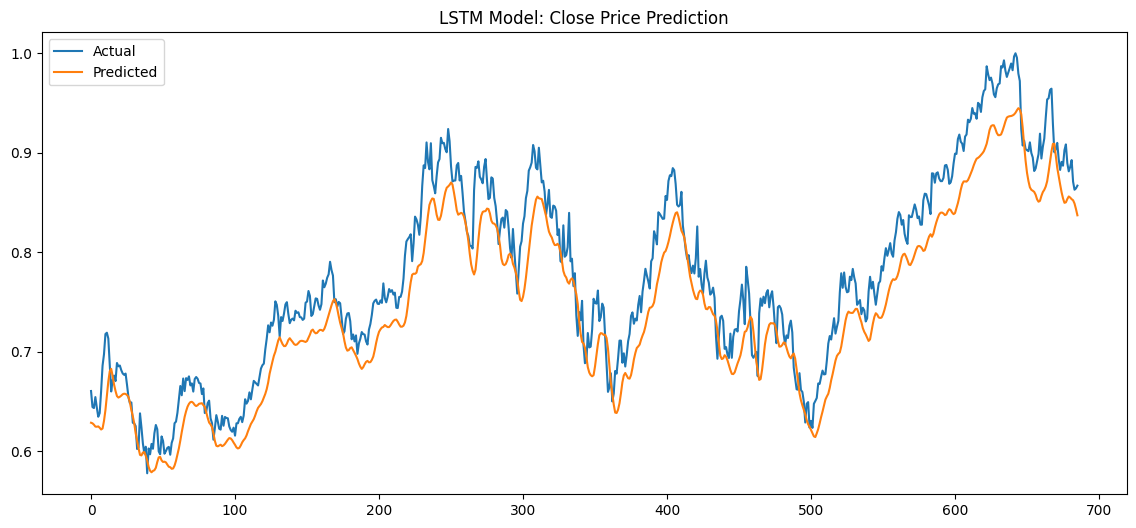

In [5]:

predicted = model.predict(X_test)
plt.figure(figsize=(14,6))
plt.plot(y_test, label="Actual")
plt.plot(predicted, label="Predicted")
plt.title("LSTM Model: Close Price Prediction")
plt.legend()
plt.show()